Alberto Morillas has 499 perfumes.


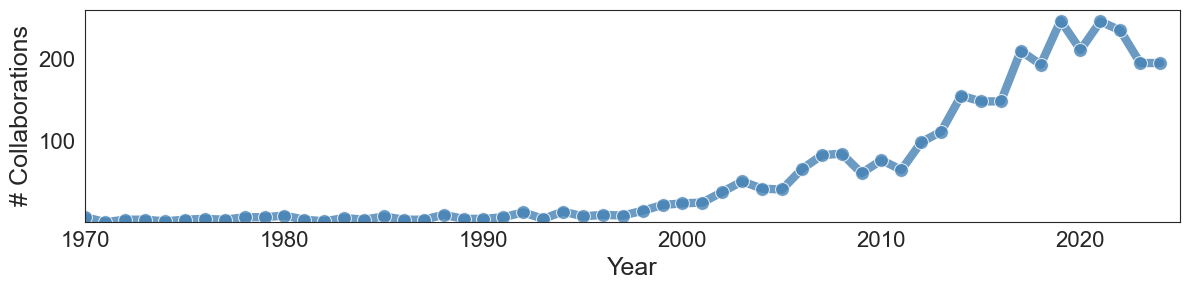

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import math
from itertools import combinations
import graph_tool.all as gt
import seaborn as sns

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []

def parse_accords(accords_str):
    """
    Parse the 'accords' column to extract accord frequencies.
    """
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

def calculate_dominant_accord(perfumer_accords):
    """
    Calculate the dominant accord for each perfumer based on accord frequencies,
    considering all accords present.
    
    For each perfumer, this function aggregates the frequencies of each accord 
    (by summing them) and then returns the accord with the highest total frequency.
    """
    aggregated = perfumer_accords.groupby(['perfumer', 'accord'])['frequency'].sum().reset_index()
    # For each perfumer, select the row with the maximum frequency
    idx = aggregated.groupby('perfumer')['frequency'].idxmax()
    dominant = aggregated.loc[idx].reset_index(drop=True)
    dominant = dominant.rename(columns={'accord': 'dominant_accord'})
    return dominant

def main():
    # Load the dataset
    csv_file = "../dataset/perfume_dataset.csv"  # Update this path as needed
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"File {csv_file} not found!")
        return

    # ------------------------------------------------------
    # Ensure 'year' is treated as an integer, if your data has that column
    # If your dataset calls this something else (e.g. 'release_year'), adjust accordingly.
    # Remove or modify this if your dataset lacks a year column.
    if 'year' in df.columns:
        df = df.dropna(subset=['year'])          # drop rows with no year
        df['year'] = df['year'].astype(int)      # convert to integer
    # ------------------------------------------------------

    # Parse the 'perfumer' and 'accords' columns
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords']   = df['accords'].apply(parse_accords)

    # Flatten the accords and associate them with perfumers
    accord_data = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords.items():
                accord_data.append({'perfumer': perfumer, 'accord': accord, 'frequency': frequency})
    perfumer_accords = pd.DataFrame(accord_data)

    # Identify the top 15 most frequent accords
    top_accords = (
        perfumer_accords.groupby('accord')['frequency']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .index.tolist()
    )

    # Calculate the dominant accord for each perfumer
    dominant_accords = calculate_dominant_accord(perfumer_accords)
    perfumer_accord_map = dominant_accords.set_index('perfumer')['dominant_accord'].to_dict()

    # Count perfumes for each perfumer
    perfumer_counts = (
        df.explode('parsed_perfumers')
        .dropna(subset=['parsed_perfumers'])
        .groupby('parsed_perfumers')['id']
        .count()
        .reset_index()
        .rename(columns={'parsed_perfumers': 'perfumer', 'id': 'perfume_count'})
    )
    # Example check for Alberto Morillas
    alberto = perfumer_counts[perfumer_counts['perfumer'].str.lower() == 'alberto morillas']
    if not alberto.empty:
        print("Alberto Morillas has", alberto['perfume_count'].values[0], "perfumes.")
    else:
        print("No data for Alberto Morillas.")

    perfumer_size_map = perfumer_counts.set_index('perfumer')['perfume_count'].to_dict()

    # Filter to keep perfumers with more than 1 perfume
    top_perfumers = perfumer_counts[perfumer_counts['perfume_count'] > 1]['perfumer'].tolist()
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_perfumers])
    df = df[df['filtered_perfumers'].apply(len) > 1]




    # ------------------------------------------------------
    # ADDITION: Calculate & plot the number of collaborations each year (1900–2024)
    # ------------------------------------------------------

    # 1) We assume 'year' is in df. Filter to collaborative perfumes only:
    # (We've already done that in df, so "df" at this point has only top-perfumers 
    #  with multiple perfumers. If you prefer the entire set, use a separate variable.)
    if 'year' in df.columns:
        # 2) Filter to the desired year range
        collab_df = df[(df['year'] >= 1900) & (df['year'] <= 2024)]

        # 3) Count how many collaborations for each year
        #    Each row in df is one perfume. Because we already have 
        #    'filtered_perfumers' length > 1, each row is a collaboration perfume.
        #    So we just need to count them by year.
        collab_year_counts = collab_df.groupby('year').size().sort_index()

        # 4) Make a list/array of years from 1900 to 2024, filling missing years with 0
        years = range(1970, 2025)
        year_counts = [collab_year_counts.get(y, 0) for y in years]

        # 5) Plot
        # Optional: set a style, e.g. "whitegrid"
        sns.set_style("white")

        plt.figure(figsize=(12, 3))
        ax = sns.lineplot(x=years, y=year_counts, color='steelblue',alpha=0.8,linewidth=6, marker='o',markersize=10)
        # Remove top and right spines
        # ax.spines["top"].set_visible(False)
        # ax.spines["right"].set_visible(False)
        # plt.yscale('symlog', linthresh=0.0001)  # or just plt.yscale('log') if you prefer

        plt.xlabel("Year", fontsize=18)
        plt.ylabel("# Collaborations", fontsize=18)
        plt.tick_params(axis='both', which='major', labelsize=16)
        plt.xlim(1970, 2025)
        plt.ylim(0.5, 260)

        plt.tight_layout()
        plt.savefig("../output/Figure_4a.svg", format="svg", dpi=300, bbox_inches="tight")

        plt.show()
    else:
        print("No 'year' column found in DataFrame—cannot plot collaborations over time.")

if __name__ == "__main__":
    main()


                   perfumer        accord   frequency
11570  Christophe Laudamiel         nutty  100.000000
11553  Christophe Laudamiel     chocolate   96.038614
11566  Christophe Laudamiel       leather   84.725624
11575  Christophe Laudamiel          rose   80.618487
11554  Christophe Laudamiel        citrus   75.982638
11545  Christophe Laudamiel         amber   75.656794
11556  Christophe Laudamiel        floral   74.459399
11547  Christophe Laudamiel       aquatic   73.202240
11560  Christophe Laudamiel         green   72.616701
11571  Christophe Laudamiel           oud   72.464027
11572  Christophe Laudamiel        ozonic   72.453190
11548  Christophe Laudamiel      aromatic   68.382273
11587  Christophe Laudamiel         woody   67.147718
11585  Christophe Laudamiel  white floral   66.576300
11559  Christophe Laudamiel        fruity   65.070277
11563  Christophe Laudamiel          iris   64.876538
11574  Christophe Laudamiel       powdery   64.649908
11576  Christophe Laudamiel 

/var/folders/ts/n9fbfxkj091_fpcsbsgj4zcxb6n5sd/T/ipykernel_29967/824054433.py:210: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(accords))


Nodes in largest component: 501


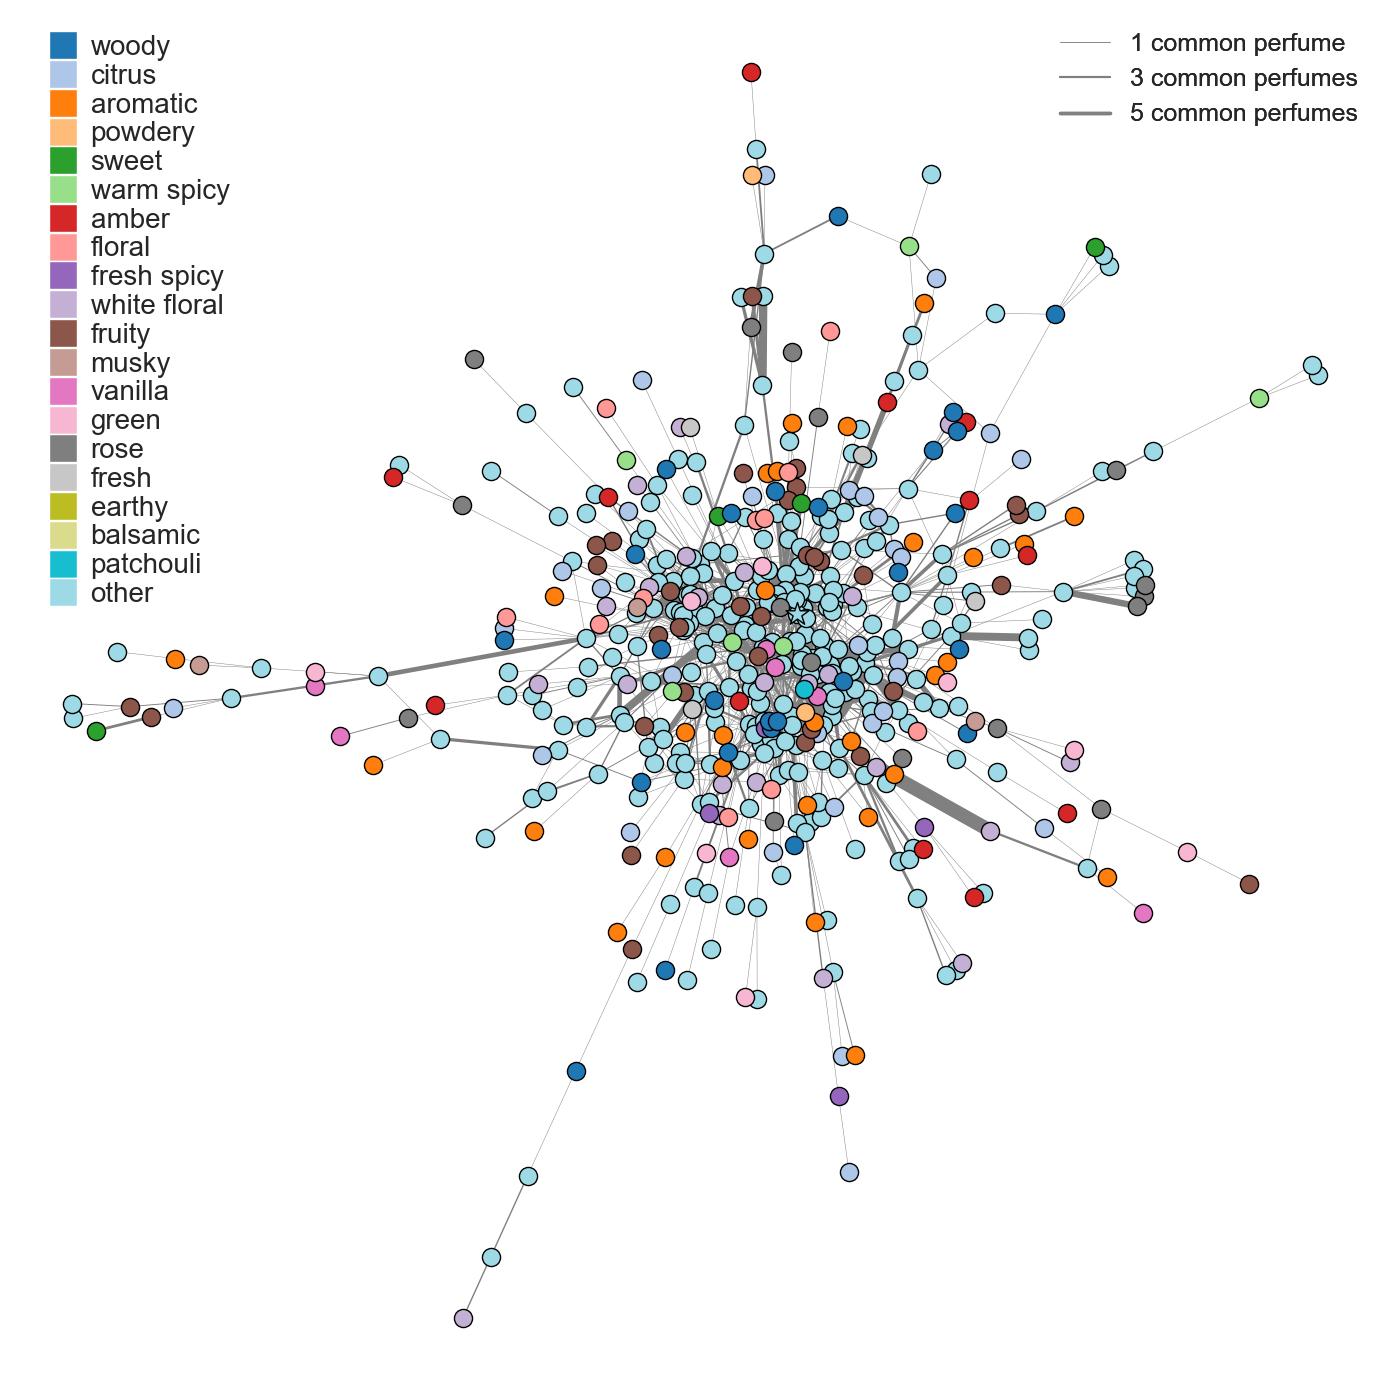

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np
import math
from itertools import combinations
import graph_tool.all as gt

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []

def parse_accords(accords_str):
    """
    Parse the 'accords' column to extract accord frequencies.
    """
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

# def calculate_dominant_accord(perfumer_accords, top_accords):
#     """
#     Calculate the dominant accord for each perfumer based on accord frequencies,
#     considering only the top accords.
#     """
#     aggregated_accords = (
#         perfumer_accords.groupby(['perfumer', 'accord'])
#         .sum('frequency')
#         .reset_index()
#         .sort_values(['perfumer', 'frequency'], ascending=[True, False])
#     )
#     dominant_accords = (
#         aggregated_accords.groupby('perfumer')
#         .first()
#         .reset_index()
#         .rename(columns={'accord': 'dominant_accord'})
#     )
#     dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
#         lambda x: x if x in top_accords else 'other'
#     )
#     return dominant_accords
# def calculate_dominant_accord(perfumer_accords, top_accords):
#     aggregated_accords = (
#         perfumer_accords.groupby(['perfumer', 'accord'])
#         .sum('frequency')
#         .reset_index()
#         .sort_values(['perfumer', 'frequency'], ascending=[True, False])
#     )
#     # Let's see what we have for Christophe Laudamiel
#     chris_rows = aggregated_accords[aggregated_accords['perfumer'] == 'Christophe Laudamiel']
#     print(chris_rows.sort_values(by='frequency', ascending=False).head(20))
#     dominant_accords = (
#         aggregated_accords.groupby('perfumer')
#         .first()      # <-- picks the single largest SUM for each perfumer
#         .reset_index()
#         .rename(columns={'accord': 'dominant_accord'})
#     )
#     dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
#         lambda x: x if x in top_accords else 'other'
#     )
#     return dominant_accords

def calculate_dominant_accord(perfumer_accords, top_accords):
    aggregated_accords = (
        perfumer_accords.groupby(['perfumer', 'accord'])['frequency']  # Select 'frequency' column
        .mean()
        .reset_index()
        .sort_values(['perfumer', 'frequency'], ascending=[True, False])
    )
    # Let's see what we have for Christophe Laudamiel
    chris_rows = aggregated_accords[aggregated_accords['perfumer'] == 'Christophe Laudamiel']
    print(chris_rows.sort_values(by='frequency', ascending=False).head(20))
    dominant_accords = (
        aggregated_accords.groupby('perfumer')
        .first()
        .reset_index()
        .rename(columns={'accord': 'dominant_accord'})
    )
    dominant_accords['dominant_accord'] = dominant_accords['dominant_accord'].apply(
        lambda x: x if x in top_accords else 'other'
    )
    return dominant_accords



# def calculate_dominant_accord(perfumer_accords):
#     """
#     Calculate the dominant accord for each perfumer based on accord frequencies,
#     considering all accords present.
    
#     For each perfumer, this function aggregates the frequencies of each accord 
#     (by summing them) and then returns the accord with the highest total frequency.
#     """
#     aggregated = perfumer_accords.groupby(['perfumer', 'accord'])['frequency'].sum().reset_index()
#     # For each perfumer, select the row with the maximum frequency
#     idx = aggregated.groupby('perfumer')['frequency'].idxmax()
#     dominant = aggregated.loc[idx].reset_index(drop=True)
#     dominant = dominant.rename(columns={'accord': 'dominant_accord'})
#     return dominant

def main():
    # Load the dataset
    csv_file = "../dataset/perfume_dataset.csv"  # Update this path as needed
    try:
        df = pd.read_csv(csv_file)
        df = df[(df['year'] >= 1900)]
    except FileNotFoundError:
        print(f"File {csv_file} not found!")
        return

    # Parse the 'perfumer' and 'accords' columns
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords'] = df['accords'].apply(parse_accords)

    # Flatten the accords and associate them with perfumers
    accord_data = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords.items():
                accord_data.append({'perfumer': perfumer, 'accord': accord, 'frequency': frequency})
    perfumer_accords = pd.DataFrame(accord_data)

    # Identify the top 15 most frequent accords
    top_accords = (
        perfumer_accords.groupby('accord')['frequency']
        .sum()
        .sort_values(ascending=False)
        .head(19)
        .index.tolist()
    )

    # Calculate the dominant accord for each perfumer
    dominant_accords = calculate_dominant_accord(perfumer_accords, top_accords)
    perfumer_accord_map = dominant_accords.set_index('perfumer')['dominant_accord'].to_dict()

    # Count perfumes for each perfumer
    perfumer_counts = (
        df.explode('parsed_perfumers')
        .dropna(subset=['parsed_perfumers'])
        .groupby('parsed_perfumers')['id']
        .count()
        .reset_index()
        .rename(columns={'parsed_perfumers': 'perfumer', 'id': 'perfume_count'})
    )
    alberto = perfumer_counts[perfumer_counts['perfumer'].str.lower() == 'alberto morillas']
    if not alberto.empty:
        print("Alberto Morillas has", alberto['perfume_count'].values[0], "perfumes.")
    else:
        print("No data for Alberto Morillas.")

    perfumer_size_map = perfumer_counts.set_index('perfumer')['perfume_count'].to_dict()

    # Filter to keep perfumers with more than 1 perfume
    top_perfumers = perfumer_counts[perfumer_counts['perfume_count'] > 0]['perfumer'].tolist()
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_perfumers])
    df = df[df['filtered_perfumers'].apply(len) > 0]

    # Create edges with weights (number of common perfumes)
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        for pair in combinations(perfumers, 2):
            if pair in edge_weights:
                edge_weights[pair] += 1
            else:
                edge_weights[pair] = 1

    # Build the graph using graph-tool
    g = gt.Graph(directed=False)
    v_label = g.new_vertex_property("string")      # Vertex label property (perfumer name)
    v_color = g.new_vertex_property("vector<double>")  # Vertex color (RGBA as list of 4 floats)
    v_size = g.new_vertex_property("double")         # Vertex size property
    e_weight = g.new_edge_property("int")            # Edge weight property
    e_width = g.new_edge_property("double")          # Edge line width property

    # Get the unique set of perfumers (nodes) from the edges
    nodes = set()
    for pair in edge_weights:
        nodes.update(pair)
    nodes = list(nodes)
    perfumer_to_vertex = {}
    for perfumer in nodes:
        v = g.add_vertex()
        perfumer_to_vertex[perfumer] = v
        v_label[v] = perfumer
        # Use a constant size (or adjust using perfumer_size_map if desired)
        v_size[v] = 170  
    # Prepare a color mapping based on dominant accords
    accords = top_accords + ['other']
    cmap = plt.cm.get_cmap('tab20', len(accords))
    accord_color_map = {accord: list(cmap(i)) for i, accord in enumerate(accords)}
    for perfumer, v in perfumer_to_vertex.items():
        dominant = perfumer_accord_map.get(perfumer, 'other')
        color = accord_color_map.get(dominant, [0.5, 0.5, 0.5, 1.0])
        v_color[v] = color

    # Add edges with weight and corresponding line width (weight/3)
    for (p1, p2), weight in edge_weights.items():
        v1 = perfumer_to_vertex[p1]
        v2 = perfumer_to_vertex[p2]
        e = g.add_edge(v1, v2)
        e_weight[e] = weight
        e_width[e] = weight / 3.0

    # Extract the largest connected component
    g_largest = gt.extract_largest_component(g)
    print(f"Nodes in largest component: {g_largest.num_vertices()}")

    # Compute layout using graph-tool's spring layout (sfdp_layout)
    # pos = gt.arf_layout(g_largest)
    # pos=gt.arf_layout(g_largest, weight=None, d=0.5, a=10, dt=0.001, epsilon=1e-06, max_iter=1, pos=None, dim=2)
    pos=gt.fruchterman_reingold_layout(g_largest, weight=None, a=None, r=11.0, scale=None, circular=False, grid=False, t_range=None, n_iter=1000, pos=None)

    # --- Now use matplotlib to manually draw the network ---
    plt.figure(figsize=(14, 14))

    # Draw edges manually
    for e in g_largest.edges():
        source = e.source()
        target = e.target()
        x_coords = [pos[source][0], pos[target][0]]
        y_coords = [pos[source][1], pos[target][1]]
        plt.plot(x_coords, y_coords, color="gray", linewidth=e_width[e])

    # Group vertices by their color (accord) for legend purposes
    color_groups = {}
    for v in g_largest.vertices():
        x, y = pos[v]
        col = tuple(v_color[v])
        if col not in color_groups:
            color_groups[col] = {'x': [], 'y': []}
        color_groups[col]['x'].append(x)
        color_groups[col]['y'].append(y)

    # Plot the vertices
    for col_key, data in color_groups.items():
        plt.scatter(data['x'], data['y'], s=170, color=[col_key], zorder=3, edgecolors='black')
    target_perfumer = "Alberto Morillas"
    if target_perfumer in perfumer_to_vertex:
        v = perfumer_to_vertex[target_perfumer]
        x, y = pos[v]
        c = tuple(v_color[v])
        # Re-plot this single node as a star marker:
        plt.scatter(
            x, 
            y, 
            s=300, 
            color=[c], 
            zorder=4, 
            edgecolors='black', 
            marker='*'   # <-- star marker
        )
    # Create a legend for accords using the color mapping
    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', label=accord,
                   markerfacecolor=accord_color_map[accord], markersize=20)
        for accord in accord_color_map
    ]
    legend_accord = plt.legend(handles=legend_elements, title="", loc='upper left',
                               fontsize=20, frameon=False, labelspacing=0.1, handletextpad=0.0)
    plt.gca().add_artist(legend_accord)

    # # ---- Add a scale legend for node size (if desired) ----
    # node_scale_values = [2, 10, 50]
    # node_scale_handles = [
    #     plt.scatter([], [], s=count*6, color='gray', label=f"{count} perfumes")
    #     for count in node_scale_values
    # ]
    # legend_node = plt.legend(handles=node_scale_handles, title="", loc='upper right',
    #                          fontsize=18, frameon=False, bbox_to_anchor=(0.93, 0.92))
    # plt.gca().add_artist(legend_node)

    # ---- Add a scale legend for edge weight ----
    edge_scale_values = [1, 3, 5]
    edge_scale_handles = [
        plt.Line2D([0], [0], color='gray', linewidth=(count/2),
                   label=f"{count} common perfume{'s' if count > 1 else ''}")
        for count in edge_scale_values
    ]
    legend_edge = plt.legend(handles=edge_scale_handles, title="", loc='upper right',
                             fontsize=18, frameon=False)
    plt.gca().add_artist(legend_edge)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("../output/Figure_4b.svg", format="svg", dpi=300)


    plt.show()

if __name__ == "__main__":
    main()


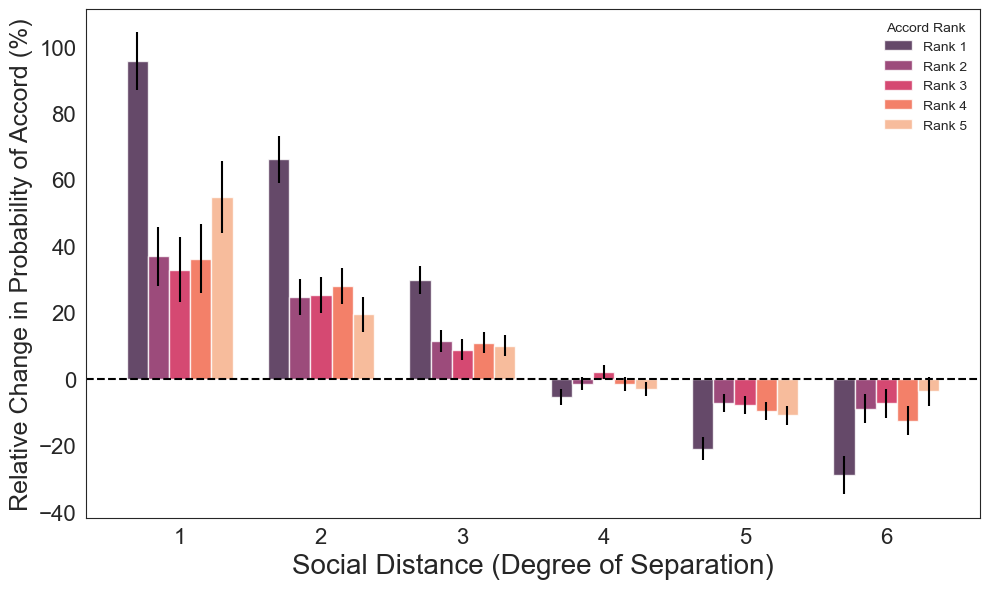


Summary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Ranks):
Degree	Mean_Relative_Increase	Std_Error
1	51.25			9.68
2	32.64			5.70
3	14.14			3.38
4	-1.90			2.17
5	-11.34			2.84
6	-12.33			4.61


In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# def parse_perfumers(perfumer_str):
#     """
#     Parse the 'perfumer' column to extract individual perfumers.
#     Expects something like: "Perfumer A, Perfumer B" or NaN.
#     Returns a list of perfumer names.
#     """
#     if pd.isna(perfumer_str):
#         return []
#     # Split by comma and strip whitespace
#     return [p.strip() for p in perfumer_str.split(",") if p.strip()]
def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            # Ensure we return a list of strings, stripped of extra whitespace
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            # Otherwise, split by comma
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []
    
def parse_accords(accords_str):
    """
    Parse the 'accords' column (JSON-like string) to extract accord frequencies.
    Example: '{"woody": 100.0, "amber": 92.07, ...}'
    Returns a dictionary {accord_name: frequency}.
    """
    if pd.isna(accords_str):
        return {}
    try:
        return ast.literal_eval(accords_str)
    except (ValueError, SyntaxError):
        return {}

def build_network(df):
    """
    Build a perfumer collaboration network from the DataFrame.
    Each row can have multiple perfumers (in 'filtered_perfumers'),
    and we create edges between each pair of perfumers in that row.
    """
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        if len(perfumers) < 2:
            continue
        for pair in combinations(perfumers, 2):
            # Sort pair so (A,B) == (B,A)
            pair = tuple(sorted(pair))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (node1, node2), weight in edge_weights.items():
        G.add_edge(node1, node2, weight=weight)

    # Extract the largest connected component to avoid isolated nodes
    if G.number_of_nodes() == 0:
        return G  # empty graph
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    return G_sub

def calculate_top_n_accords(perfumer_accords, top_accords, n=5):
    """
    Returns a DataFrame with columns:
      [perfumer, accord, normalized_count, rank]
    where rank = 1..n for the top-n accords of each perfumer, based on normalized counts.
    """
    # Step 1: Count number of times each (perfumer, accord) pair appears
    perfumer_accords_count = (
        perfumer_accords
        .groupby(['perfumer', 'accord'], as_index=False)['count']
        .sum()
    )

    # Step 2: Normalize counts per perfumer
    perfumer_total_counts = perfumer_accords_count.groupby('perfumer')['count'].transform('sum')
    perfumer_accords_count['normalized_count'] = perfumer_accords_count['count'] / perfumer_total_counts

    # Step 3: Sort accords by normalized count per perfumer
    aggregated_accords = (
        perfumer_accords_count
        .sort_values(['perfumer', 'normalized_count'], ascending=[True, False])
    )

    # Step 4: Keep top-n rows per perfumer
    top_accords_df = aggregated_accords.groupby('perfumer').head(n).copy()

    # Optional: Label if you want to filter global top accords (right now skipped)
    # top_accords_df['accord'] = top_accords_df['accord'].apply(
    #     lambda x: x if x in top_accords else 'Other'
    # )

    # Step 5: Assign rank (1 = highest normalized count)
    top_accords_df['rank'] = (
        top_accords_df.groupby('perfumer')['normalized_count']
        .rank(method='first', ascending=False)
        .astype(int)
    )

    # Step 6: Keep only ranks <= n
    return top_accords_df[top_accords_df['rank'] <= n]


def get_rank_accord_map(top_accords_df, rank):
    """
    For a given rank (1..5), return a dict {perfumer: accord_for_that_rank}.
    If a perfumer doesn't have that rank, it won't appear in the map.
    """
    rank_df = top_accords_df[top_accords_df['rank'] == rank]
    return rank_df.set_index('perfumer')['accord'].to_dict()

def compute_probability_by_distance_for_map(G, perfumer_accord_map, max_distance=6):
    """
    Given a networkx Graph G and a dict {perfumer: accord},
    compute the probability that two connected perfumers share the same accord
    at each social distance from 1..max_distance.
    Returns {distance: probability}.
    """
    if G.number_of_nodes() == 0:
        return {d: 0.0 for d in range(1, max_distance+1)}

    distances = dict(nx.all_pairs_shortest_path_length(G))

    observed_counts = {d: 0 for d in range(1, max_distance+1)}
    total_counts = {d: 0 for d in range(1, max_distance+1)}

    for node1 in distances:
        for node2, dist in distances[node1].items():
            if 1 <= dist <= max_distance:
                total_counts[dist] += 1
                # If both nodes have a rank accord assigned and they match
                if (perfumer_accord_map.get(node1) == perfumer_accord_map.get(node2)
                        and node1 in perfumer_accord_map
                        and node2 in perfumer_accord_map):
                    observed_counts[dist] += 1

    observed_probabilities = {}
    for d in range(1, max_distance+1):
        if total_counts[d] > 0:
            observed_probabilities[d] = observed_counts[d] / total_counts[d]
        else:
            observed_probabilities[d] = 0.0
    return observed_probabilities

def simulate_random_networks_for_map(G, perfumer_accord_map, num_simulations=50, max_distance=6):
    """
    Randomly shuffle the accord assignments among the *existing nodes in G*.
    Return two dicts:
      - random_mean: {distance: mean_probability}
      - random_std:  {distance: std_of_probability_across_simulations}
    """
    if G.number_of_nodes() == 0:
        # Return all zeros
        random_mean = {d: 0.0 for d in range(1, max_distance+1)}
        random_std = {d: 0.0 for d in range(1, max_distance+1)}
        return random_mean, random_std

    nodes = list(G.nodes())
    # We only have a rank-based accord for some subset of nodes
    # For nodes not in perfumer_accord_map, let's label them None
    # so the random assignment can be consistent in size
    assigned_accords = []
    for n in nodes:
        if n in perfumer_accord_map:
            assigned_accords.append(perfumer_accord_map[n])
        else:
            assigned_accords.append(None)

    distances = dict(nx.all_pairs_shortest_path_length(G))
    # Precompute total_counts to avoid repeating
    total_counts = {d: 0 for d in range(1, max_distance+1)}
    for node1 in distances:
        for node2, dist in distances[node1].items():
            if 1 <= dist <= max_distance:
                total_counts[dist] += 1

    probabilities_per_sim = []
    for _ in range(num_simulations):
        # Shuffle the assigned_accords in-place
        np.random.shuffle(assigned_accords)
        shuffled_map = dict(zip(nodes, assigned_accords))

        simulated_counts = {d: 0 for d in range(1, max_distance+1)}

        for node1 in distances:
            for node2, dist in distances[node1].items():
                if 1 <= dist <= max_distance:
                    if (shuffled_map[node1] is not None
                            and shuffled_map[node2] is not None
                            and shuffled_map[node1] == shuffled_map[node2]):
                        simulated_counts[dist] += 1

        # Compute the probability for each distance
        sim_prob = {}
        for d in range(1, max_distance+1):
            if total_counts[d] > 0:
                sim_prob[d] = simulated_counts[d] / total_counts[d]
            else:
                sim_prob[d] = 0.0
        probabilities_per_sim.append(sim_prob)

    # Now compute mean + std across all simulations
    random_mean = {d: 0.0 for d in range(1, max_distance+1)}
    random_std = {d: 0.0 for d in range(1, max_distance+1)}

    for d in range(1, max_distance+1):
        dist_values = [sim[d] for sim in probabilities_per_sim]
        random_mean[d] = np.mean(dist_values)
        random_std[d] = np.std(dist_values, ddof=1)  # sample std

    return random_mean, random_std

def main():
    # -------------------------------
    # 1) Load the CSV
    # -------------------------------
    csv_file = "../dataset/perfume_dataset.csv"
    df = pd.read_csv(csv_file)
    # df = df[df['weights_sum'] > 286].copy()

    # -------------------------------
    # 2) Parse perfumers & accords
    # -------------------------------
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_accords'] = df['accords'].apply(parse_accords)

    # -------------------------------
    # 3) Build the perfumer_accords DataFrame
    #    from each row's perfumers & accords
    # -------------------------------
    perfumer_accords_list = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        accords_dict = row['parsed_accords']
        for perfumer in perfumers:
            for accord, frequency in accords_dict.items():
                perfumer_accords_list.append({
                    'perfumer': perfumer,
                    'accord': accord,
                    'count': 1
                })

    perfumer_accords = pd.DataFrame(perfumer_accords_list)
    if perfumer_accords.empty:
        print("No perfumer_accords found. Check CSV parsing.")
        return

    # Identify all accords globally
    top_accords = (
        perfumer_accords
        .groupby('accord')['count']
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )

    # -------------------------------
    # 4) Compute top 5 accords per perfumer
    # -------------------------------
    top_5_df = calculate_top_n_accords(perfumer_accords, top_accords, n=5)
    if top_5_df.empty:
        print("No top-5 accords found. Possibly no data or mismatch.")
        return

    # -------------------------------
    # 5) Build the collaboration network
    #    We filter out rows with no valid perfumers
    # -------------------------------
    # For simplicity, let's use the same parsed_perfumers but only keep rows that have at least 2
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_5_df['perfumer'].unique()])
    # Keep only rows that have at least 2 perfumers after filtering
    df = df[df['filtered_perfumers'].apply(len) > 1].copy()

    G = build_network(df)
    if G.number_of_nodes() == 0:
        print("Network is empty or only has isolated nodes. No plot will be generated.")
        return

    max_dist = 6

    # We'll store results for each rank in these dicts:
    observed_probs_by_rank = {}
    random_mean_by_rank = {}
    random_std_by_rank = {}

    # -------------------------------
    # 6) Loop over ranks 1..5, compute observed & random
    # -------------------------------
    for rank in range(1, 6):
        # Build a map {perfumer: accord} for this rank
        rank_map = get_rank_accord_map(top_5_df, rank)

        # Observed
        obs_probs = compute_probability_by_distance_for_map(G, rank_map, max_distance=max_dist)
        observed_probs_by_rank[rank] = obs_probs

        # Random
        r_mean, r_std = simulate_random_networks_for_map(G, rank_map, num_simulations=10000, max_distance=max_dist)
        random_mean_by_rank[rank] = r_mean
        random_std_by_rank[rank] = r_std

    # -------------------------------
    # 7) Compute Relative Increase + Error Bars
    # -------------------------------
    relative_increase = {}
    relative_increase_err = {}

    for rank in range(1, 6):
        relative_increase[rank] = {}
        relative_increase_err[rank] = {}
        for d in range(1, max_dist+1):
            obs = observed_probs_by_rank[rank][d]
            r_mean = random_mean_by_rank[rank][d]
            r_std = random_std_by_rank[rank][d]

            if r_mean > 0:
                ri = (obs - r_mean) / r_mean * 100
                # approximate error bar from random std
                ri_err = (r_std / r_mean) * 100
            else:
                ri = 0.0
                ri_err = 0.0

            relative_increase[rank][d] = ri
            relative_increase_err[rank][d] = ri_err

    # -------------------------------
    # 8) Plot All Five Ranks in One Grouped Bar Plot
    # -------------------------------
    sns.set_style("white")
    palette = sns.color_palette("rocket", 5)  # nice color palette for 5 ranks

    distances = np.arange(1, max_dist+1)  # [1,2,3,4,5,6]
    width = 0.15
    offset = -2 * width

    plt.figure(figsize=(10, 6))

    for i, rank in enumerate(range(1, 6)):
        ri_vals = [relative_increase[rank][d] for d in distances]
        ri_errs = [relative_increase_err[rank][d] for d in distances]
        x_positions = distances + offset + i * width

        plt.bar(
            x_positions,
            ri_vals,
            yerr=ri_errs,
            width=width,
            color=palette[i],
            alpha=0.8,
            label=f"Rank {rank}"
        )

    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=20)
    plt.ylabel("Relative Change in Probability of Accord (%)", fontsize=18)
    # plt.title("Effect of Social Distance on Top-5 Accord Clustering", fontsize=14)
    plt.legend(title="Accord Rank",frameon=False)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig("../output/Figure_4c.svg", format="svg", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    # -------------------------------
    # 9) Print summary table of relative increase
    # -------------------------------
    print("\nSummary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Ranks):")
    print("Degree\tMean_Relative_Increase\tStd_Error")

    for d in distances:
        # Collect values across ranks
        ri_vals = [relative_increase[rank][d] for rank in range(1, 6)]
        ri_errs = [relative_increase_err[rank][d] for rank in range(1, 6)]

        # Compute mean and std of the relative increase across ranks
        mean_ri = np.mean(ri_vals)
        mean_err = np.mean(ri_errs)

        print(f"{d}\t{mean_ri:.2f}\t\t\t{mean_err:.2f}")


if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# -------------------------------
# Parsing Functions
# -------------------------------

# def parse_perfumers(perfumer_str):
#     """
#     Parse the 'perfumer' column to extract individual perfumers.
#     Expects something like: "Perfumer A, Perfumer B" or NaN.
#     Returns a list of perfumer names.
#     """
#     if pd.isna(perfumer_str):
#         return []
#     return [p.strip() for p in perfumer_str.split(",") if p.strip()]
def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        # If it looks like a list, parse it
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            # Ensure we return a list of strings, stripped of extra whitespace
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip() != ""]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned != "" else []
        else:
            # Otherwise, split by comma
            return [p.strip() for p in s.split(",") if p.strip() != ""]
    except Exception:
        return []
def parse_top_notes(notes_str):
    """
    Parse the 'notes' column (JSON-like string) to extract note info.
    Example:
    '[{"Saffron": {"weight": 1, "weight_tenet": 100}}, {"Rose": {"weight": 1, "weight_tenet": 100}}, ...]'
    Returns a list of (note, weight) or (note, 1) if you prefer, but we'll just keep the note name.
    """
    if pd.isna(notes_str):
        return []
    try:
        raw_list = ast.literal_eval(notes_str)
    except (ValueError, SyntaxError):
        return []
    results = []
    for note_dict in raw_list:
        for note, vals in note_dict.items():
            # We don't need the actual 'weight' or 'weight_tenet' for counting occurrences
            results.append(note)
    return results

# -------------------------------
# Network Building Functions
# -------------------------------

def build_network(df):
    """
    Build a perfumer collaboration network from the DataFrame.
    Uses the 'filtered_perfumers' column and creates an edge between every pair.
    Returns the subgraph corresponding to the largest connected component.
    """
    edge_weights = {}
    for perfumers in df['filtered_perfumers']:
        if len(perfumers) < 2:
            continue
        for pair in combinations(perfumers, 2):
            pair = tuple(sorted(pair))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (node1, node2), weight in edge_weights.items():
        G.add_edge(node1, node2, weight=weight)

    if G.number_of_nodes() == 0:
        return G
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    return G_sub

# -------------------------------
# Top Notes Calculation Functions
# -------------------------------

def calculate_top_n_notes(perfumer_notes, top_notes, n=5):
    """
    Returns a DataFrame with columns:
      [perfumer, note, normalized_count, rank]
    where for each perfumer the top-n notes are selected (sorted by normalized count).
    Notes not in the global top_notes list are labeled as 'Other'.
    """
    # Step 1: Aggregate counts by (perfumer, note)
    aggregated_notes = (
        perfumer_notes
        .groupby(['perfumer', 'note'], as_index=False)['count']
        .sum()
    )

    # Step 2: Normalize counts per perfumer
    perfumer_total_counts = aggregated_notes.groupby('perfumer')['count'].transform('sum')
    aggregated_notes['normalized_count'] = aggregated_notes['count'] / perfumer_total_counts

    # Step 3: Sort by normalized count
    aggregated_notes = aggregated_notes.sort_values(['perfumer', 'normalized_count'], ascending=[True, False])

    # Step 4: Keep top-n notes per perfumer
    top_notes_df = aggregated_notes.groupby('perfumer').head(n).copy()

    # Step 5: Label notes not in the global top_notes list as 'Other'
    top_notes_df['note'] = top_notes_df['note'].apply(lambda x: x if x in top_notes else 'Other')

    # Step 6: Rank within each perfumer (1 = highest normalized count)
    top_notes_df['rank'] = (
        top_notes_df.groupby('perfumer')['normalized_count']
        .rank(method='first', ascending=False)
        .astype(int)
    )

    # Step 7: Keep only ranks <= n
    return top_notes_df[top_notes_df['rank'] <= n]


def get_rank_note_map(top_notes_df, rank):
    """
    For a given rank (1..5), return a dict {perfumer: note_for_that_rank}.
    """
    rank_df = top_notes_df[top_notes_df['rank'] == rank]
    return rank_df.set_index('perfumer')['note'].to_dict()

# -------------------------------
# Network Probability Functions
# -------------------------------

def compute_probability_by_distance_for_map(G, perfumer_note_map, max_distance=6):
    """
    Given a networkx Graph G and a dict {perfumer: note},
    compute the probability that two connected perfumers share the same note
    at each social distance from 1..max_distance.
    Returns a dict {distance: probability}.
    """
    if G.number_of_nodes() == 0:
        return {d: 0.0 for d in range(1, max_distance+1)}
    
    distances = dict(nx.all_pairs_shortest_path_length(G))
    observed_counts = {d: 0 for d in range(1, max_distance+1)}
    total_counts = {d: 0 for d in range(1, max_distance+1)}
    
    for node1 in distances:
        for node2, dist in distances[node1].items():
            if 1 <= dist <= max_distance:
                total_counts[dist] += 1
                if (perfumer_note_map.get(node1) == perfumer_note_map.get(node2)
                        and node1 in perfumer_note_map
                        and node2 in perfumer_note_map):
                    observed_counts[dist] += 1
                    
    observed_probabilities = {}
    for d in range(1, max_distance+1):
        if total_counts[d] > 0:
            observed_probabilities[d] = observed_counts[d] / total_counts[d]
        else:
            observed_probabilities[d] = 0.0
    return observed_probabilities

def simulate_random_networks_for_map(G, perfumer_note_map, num_simulations=10000, max_distance=6):
    """
    Randomly shuffle the note assignments among the nodes in G.
    Return two dicts:
      - random_mean: {distance: mean_probability}
      - random_std:  {distance: std_probability}
    """
    if G.number_of_nodes() == 0:
        random_mean = {d: 0.0 for d in range(1, max_distance+1)}
        random_std = {d: 0.0 for d in range(1, max_distance+1)}
        return random_mean, random_std

    nodes = list(G.nodes())
    assigned_notes = []
    for n in nodes:
        if n in perfumer_note_map:
            assigned_notes.append(perfumer_note_map[n])
        else:
            assigned_notes.append(None)
    
    distances = dict(nx.all_pairs_shortest_path_length(G))
    total_counts = {d: 0 for d in range(1, max_distance+1)}
    for node1 in distances:
        for node2, dist in distances[node1].items():
            if 1 <= dist <= max_distance:
                total_counts[dist] += 1
    
    probabilities_per_sim = []
    for _ in range(num_simulations):
        np.random.shuffle(assigned_notes)
        shuffled_map = dict(zip(nodes, assigned_notes))
        simulated_counts = {d: 0 for d in range(1, max_distance+1)}
        for node1 in distances:
            for node2, dist in distances[node1].items():
                if 1 <= dist <= max_distance:
                    if (shuffled_map[node1] is not None and shuffled_map[node2] is not None and
                        shuffled_map[node1] == shuffled_map[node2]):
                        simulated_counts[dist] += 1
        sim_prob = {}
        for d in range(1, max_distance+1):
            if total_counts[d] > 0:
                sim_prob[d] = simulated_counts[d] / total_counts[d]
            else:
                sim_prob[d] = 0.0
        probabilities_per_sim.append(sim_prob)
    
    random_mean = {d: np.mean([sim[d] for sim in probabilities_per_sim]) for d in range(1, max_distance+1)}
    random_std = {d: np.std([sim[d] for sim in probabilities_per_sim], ddof=1) for d in range(1, max_distance+1)}
    return random_mean, random_std

# -------------------------------
# Main Function
# -------------------------------

def main():
    # 1) Load the CSV and optionally filter if you want
    csv_file = "../dataset/perfume_dataset.csv"
    df = pd.read_csv(csv_file)
    
    # Example filter (adjust or remove as needed)
    df = df[df['weights_sum'] > 10].copy()
    
    # 2) Parse perfumers & notes (just the note names).
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)
    df['parsed_top_notes'] = df['notes'].apply(parse_top_notes)
    
    # 3) Build the perfumer_notes DataFrame by counting occurrences of each note for each perfumer.
    perfumer_notes_list = []
    for _, row in df.iterrows():
        perfumers = row['parsed_perfumers']
        notes = row['parsed_top_notes']  # list of note names
        for perfumer in perfumers:
            for note in notes:
                # We'll just add 1 for each (perfumer, note) occurrence
                perfumer_notes_list.append({
                    'perfumer': perfumer,
                    'note': note,
                    'count': 1
                })
    perfumer_notes = pd.DataFrame(perfumer_notes_list)
    if perfumer_notes.empty:
        print("No perfumer_notes found. Check CSV parsing.")
        return
    
    # Identify top 20 notes globally by summing the 'count'
    top_notes = (
        perfumer_notes
        .groupby('note')['count']
        .sum()
        .sort_values(ascending=False)
        #.head(200000)
        .index.tolist()
    )
    
    # 4) Compute top 5 notes per perfumer.
    top_5_df = calculate_top_n_notes(perfumer_notes, top_notes, n=5)
    if top_5_df.empty:
        print("No top-5 notes found. Possibly no data or mismatch.")
        return
    
    # 5) Build the collaboration network.
    # Use parsed_perfumers but only keep rows that have at least 2 valid perfumers.
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p in top_5_df['perfumer'].unique()])
    df = df[df['filtered_perfumers'].apply(len) > 1].copy()
    G = build_network(df)
    if G.number_of_nodes() == 0:
        print("Network is empty or has only isolated nodes. No plot will be generated.")
        return
    
    max_dist = 6
    
    # 6) For each rank (1..5), compute observed and randomized probabilities.
    observed_probs_by_rank = {}
    random_mean_by_rank = {}
    random_std_by_rank = {}
    
    for rank in range(1, 6):
        rank_map = get_rank_note_map(top_5_df, rank)
        obs_probs = compute_probability_by_distance_for_map(G, rank_map, max_distance=max_dist)
        observed_probs_by_rank[rank] = obs_probs
        r_mean, r_std = simulate_random_networks_for_map(G, rank_map, num_simulations=10000, max_distance=max_dist)
        random_mean_by_rank[rank] = r_mean
        random_std_by_rank[rank] = r_std
    
    # 7) Compute Relative Increase + Error Bars.
    relative_increase = {}
    relative_increase_err = {}
    
    for rank in range(1, 6):
        relative_increase[rank] = {}
        relative_increase_err[rank] = {}
        for d in range(1, max_dist+1):
            obs = observed_probs_by_rank[rank][d]
            r_mean = random_mean_by_rank[rank][d]
            r_std = random_std_by_rank[rank][d]
            if r_mean > 0:
                ri = (obs - r_mean) / r_mean * 100
                ri_err = (r_std / r_mean) * 100
            else:
                ri = 0.0
                ri_err = 0.0
            relative_increase[rank][d] = ri
            relative_increase_err[rank][d] = ri_err
    
    # 8) Plot All Five Ranks in One Grouped Bar Plot.
    sns.set_style("white")
    palette = sns.color_palette("rocket", 5)
    
    distances = np.arange(1, max_dist+1)  # [1,2,3,4,5,6]
    width = 0.15
    offset = -2 * width
    
    plt.figure(figsize=(10, 6))
    
    for i, rank in enumerate(range(1, 6)):
        ri_vals = [relative_increase[rank][d] for d in distances]
        ri_errs = [relative_increase_err[rank][d] for d in distances]
        x_positions = distances + offset + i * width
        plt.bar(
            x_positions,
            ri_vals,
            yerr=ri_errs,
            width=width,
            color=palette[i],
            alpha=0.8,
            label=f"Rank {rank}"
        )
    
    plt.xticks(distances, distances)
    plt.axhline(y=0, color='black', linestyle='dashed')
    plt.xlabel("Social Distance (Degree of Separation)", fontsize=20)
    plt.ylabel("Relative Change in Probability of Notes (%)", fontsize=18)
    # plt.title("Effect of Social Distance on Top-5 Accord Clustering", fontsize=14)
    plt.legend(title="Notes Rank",frameon=False)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig("../output/Figure_4d.svg", format="svg", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    # -------------------------------
    # 9) Print summary table of relative increase for NOTES
    # -------------------------------
    print("\nSummary of Relative Change (%) and Error by Degree of Separation (Averaged across Top 5 Note Ranks):")
    print("Degree\tMean_Relative_Increase\tStd_Error")

    for d in distances:
        # Collect values across ranks
        ri_vals = [relative_increase[rank][d] for rank in range(1, 6)]
        ri_errs = [relative_increase_err[rank][d] for rank in range(1, 6)]

        # Compute mean and std of the relative increase across ranks
        mean_ri = np.mean(ri_vals)
        mean_err = np.mean(ri_errs)

        print(f"{d}\t{mean_ri:.2f}\t\t\t{mean_err:.2f}")


if __name__ == "__main__":
    main()


In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import spearmanr  # For Spearman correlation

def parse_perfumers(perfumer_str):
    """
    Parse the 'perfumer' column to extract individual perfumers.
    If the cell is a string representation of a list, use ast.literal_eval.
    """
    try:
        if pd.isna(perfumer_str):
            return []
        s = perfumer_str.strip()
        if s.startswith('[') and s.endswith(']'):
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(name).strip() for name in parsed if str(name).strip()]
            else:
                cleaned = str(parsed).strip()
                return [cleaned] if cleaned else []
        else:
            return [p.strip() for p in s.split(",") if p.strip()]
    except Exception:
        return []

def build_network(df, perfumer_col='filtered_perfumers'):
    """
    Build a perfumer collaboration network from the DataFrame.
    Each row can have multiple perfumers; we create edges
    between every pair of perfumers in that row.
    """
    edge_weights = {}
    for perfumers in df[perfumer_col]:
        if len(perfumers) < 2:
            continue
        for pair in combinations(perfumers, 2):
            pair = tuple(sorted(pair))
            edge_weights[pair] = edge_weights.get(pair, 0) + 1

    G = nx.Graph()
    for (n1, n2), weight in edge_weights.items():
        G.add_edge(n1, n2, weight=weight)

    if G.number_of_nodes() == 0:
        return G

    # Extract the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    return G_sub

def main():
    # -------------------------------------------------
    # 1) Load CSV
    # -------------------------------------------------
    csv_file = "enhanced_with_ratings.csv"
    df = pd.read_csv(csv_file)

    # -------------------------------------------------
    # 2) Parse perfumers
    # -------------------------------------------------
    df['parsed_perfumers'] = df['perfumer'].apply(parse_perfumers)

    # -------------------------------------------------
    # 3) Build collaboration network
    # -------------------------------------------------
    df['filtered_perfumers'] = df['parsed_perfumers'].apply(lambda x: [p for p in x if p.strip()])
    df_for_network = df[df['filtered_perfumers'].apply(len) > 1].copy()

    G = build_network(df_for_network)
    if G.number_of_nodes() == 0:
        print("No connected network found. Exiting.")
        return

    # -------------------------------------------------
    # 4) Compute centralities: Eigenvector, Degree
    # -------------------------------------------------
    ec_dict = nx.eigenvector_centrality(G, max_iter=1000)  # {perfumer: eigenvector}
    deg_dict = dict(G.degree())                            # {perfumer: degree}

    centrality_df = pd.DataFrame({
        'perfumer': list(G.nodes()),
        'eigenvector': [ec_dict[n] for n in G.nodes()],
        'degree': [deg_dict[n] for n in G.nodes()]
    })

    # -------------------------------------------------
    # 5) Aggregate Perfume_Complexity + innovation_score
    #    capturing both mean & std for each perfumer
    # -------------------------------------------------
    expanded_rows = []
    for _, row in df.iterrows():
        complexity = row.get('Perfume_Complexity', np.nan)
        innovation = row.get('innovation_score', np.nan)
        for perf in row['parsed_perfumers']:
            expanded_rows.append({
                'perfumer': perf,
                'Perfume_Complexity': complexity,
                'innovation_score': innovation
            })

    expanded_df = pd.DataFrame(expanded_rows)
    stats_df = expanded_df.groupby('perfumer', as_index=False).agg({
        'Perfume_Complexity': ['mean', 'std'],
        'innovation_score': ['mean', 'std']
    })
    # Flatten multi-level columns
    stats_df.columns = [
        'perfumer',
        'Perfume_Complexity_mean', 'Perfume_Complexity_std',
        'innovation_score_mean', 'innovation_score_std'
    ]

    # -------------------------------------------------
    # 6) Merge centralities with stats
    # -------------------------------------------------
    merged = pd.merge(centrality_df, stats_df, on='perfumer', how='inner')
    merged.dropna(subset=[
        'eigenvector',
        'degree',
        'Perfume_Complexity_mean',
        'Perfume_Complexity_std',
        'innovation_score_mean',
        'innovation_score_std'
    ], inplace=True)

    # -------------------------------------------------
    # 7) Set Seaborn style
    # -------------------------------------------------
    sns.set_style("white")

    # -------------------------------------------------
    # 8) Plot 2×2:  Row=0 => Complexity; Row=1 => Innovation
    #               Col=0 => Eigenvector; Col=1 => Degree
    # -------------------------------------------------
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

    def plot_reg_with_errorbars(ax, xvals, yvals, yerrs, x_label, y_label):
        # 1) Scatter + error bars
        ax.errorbar(xvals, yvals, yerr=yerrs, fmt='o', alpha=0.6, color='steelblue',zorder=1)

        # 2) Regression line
        temp_df = pd.DataFrame({'x': xvals, 'y': yvals})
        sns.regplot(
            x='x', y='y',
            data=temp_df,
            ci=95,
            scatter=False,
            color='red',
            ax=ax,
            line_kws={'zorder': 2}
        )

        # 3) Spearman correlation
        rho, pval = spearmanr(xvals, yvals)
        pval_formatted = round(float(f"{pval:.2g}"), 4)
        text_str = f"$\\it{{\\rho}}$ = {rho:.2f}\np = {pval_formatted}"
        ax.text(
            0.6, 0.95, text_str,
            transform=ax.transAxes,
            fontsize=18,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=1, boxstyle='round')
        )

        # 4) Aesthetics
        ax.set_xlabel(x_label, fontsize=22)
        ax.set_ylabel(y_label, fontsize=22)
        ax.tick_params(labelsize=18)
        ax.grid(False)


    # ========== Subplots ==========

    # (0, 0) => Eigenvector vs. Complexity
    plot_reg_with_errorbars(
        axs[0, 1],
        merged['eigenvector'],
        merged['Perfume_Complexity_mean'],
        merged['Perfume_Complexity_std'],
        x_label="",  # or "Eigenvector Centrality"
        y_label=""
    )

    # (0, 1) => Degree vs. Complexity
    plot_reg_with_errorbars(
        axs[0, 0],
        merged['degree'],
        merged['Perfume_Complexity_mean'],
        merged['Perfume_Complexity_std'],
        x_label="",
        y_label="Perfume Complexity"
    )

    # (1, 0) => Eigenvector vs. Innovation
    plot_reg_with_errorbars(
        axs[1, 1],
        merged['eigenvector'],
        merged['innovation_score_mean'],
        merged['innovation_score_std'],
        x_label="Perfumer Eigenvector Centrality",
        y_label=""
    )

    # (1, 1) => Degree vs. Innovation
    plot_reg_with_errorbars(
        axs[1, 0],
        merged['degree'],
        merged['innovation_score_mean'],
        merged['innovation_score_std'],
        x_label="Perfumer Degree",
        y_label="Perfume Innovation"
    )

    plt.tight_layout(rect=[0,0,1,1])
    plt.savefig("../output/Figure_4e.svg", format="svg", dpi=300, bbox_inches="tight")


    plt.show()

if __name__ == "__main__":
    main()
